# Linear Kalman Filter — Performance Analysis

Evaluates the GPS/IMU sensor fusion node against two test scenarios:
- **Bag 02**: Robot stationary (heading East) — tests noise reduction
- **Bag 03**: Robot moving straight North at constant velocity — tests tracking

Sensor noise characterization is in `01_Static_sensor_noise_measurement/Static_sensor_noise_analysis.ipynb`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

typestore = get_typestore(Stores.ROS2_HUMBLE)

DATA_DIR  = Path(r'C:\Users\steff\Documents\gps_autonomous_robot\04_Data')
BAG_STATIC  = DATA_DIR / '02_Linear_KF_static_measurement'  / 'rosbag2_2026_06_25-00_42_24'
BAG_DYNAMIC = DATA_DIR / '03_Linear_KF_dynamic_measurement_straight' / 'rosbag2_2026_06_25-00_54_34'

R_EARTH = 6_371_000.0   # metres — matches sensor_fusion_node.py

# ── plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
GPS_COLOR    = '#e06c1f'
FILTER_COLOR = '#1f77b4'
IMU_COLOR    = '#2ca02c'
print('Setup complete.')

Setup complete.


In [2]:
def load_bag(bag_path: Path, topics: list[str]) -> dict[str, pd.DataFrame]:
    """Load selected topics from a ROS2 bag into DataFrames keyed by topic."""
    buffers: dict[str, list] = {t: [] for t in topics}
    with AnyReader([bag_path], default_typestore=typestore) as reader:
        conns = [c for c in reader.connections if c.topic in topics]
        for conn, timestamp, raw in reader.messages(connections=conns):
            msg = reader.deserialize(raw, conn.msgtype)
            row = {'t_ns': timestamp}
            t = conn.topic
            if t == '/gps/fix':
                if msg.status.status < 0:
                    continue
                row.update(lat=msg.latitude, lon=msg.longitude, alt=msg.altitude)
            elif t == '/odom':
                row.update(
                    x=msg.pose.pose.position.x,
                    y=msg.pose.pose.position.y,
                    vx=msg.twist.twist.linear.x,
                    vy=msg.twist.twist.linear.y,
                    qz=msg.pose.pose.orientation.z,
                    qw=msg.pose.pose.orientation.w,
                )
            elif t == '/imu/data_raw':
                row.update(
                    ax=msg.linear_acceleration.x,
                    ay=msg.linear_acceleration.y,
                    az=msg.linear_acceleration.z,
                    gz=msg.angular_velocity.z,
                )
            buffers[t].append(row)
    result = {}
    for t, rows in buffers.items():
        if rows:
            df = pd.DataFrame(rows)
            df['t_s'] = (df['t_ns'] - df['t_ns'].iloc[0]) / 1e9
            result[t] = df
    return result


def latlon_to_enu(lat, lon, lat0, lon0):
    """Convert lat/lon arrays to local ENU metres relative to origin (lat0, lon0)."""
    dx = (np.radians(lon) - np.radians(lon0)) * np.cos(np.radians(lat0)) * R_EARTH
    dy = (np.radians(lat) - np.radians(lat0)) * R_EARTH
    return dx, dy


def heading_from_quat(qz, qw):
    """Extract yaw angle [rad] from 2-D quaternion (x=0, y=0, z=qz, w=qw)."""
    return 2 * np.arctan2(qz, qw)

print('Helpers defined.')

Helpers defined.


---
## 1  Static Test — Robot Stationary (Bag 02)
**Condition**: Robot placed still, heading = East (0°), duration ≈ 239 s  
**Goal**: Verify the filter reduces GPS position noise without introducing velocity drift.

In [3]:
static = load_bag(BAG_STATIC, ['/gps/fix', '/odom'])
gps_s = static['/gps/fix']
odom_s = static['/odom']

# Use first 10 GPS readings as origin (matches filter initialisation)
lat0 = gps_s['lat'].iloc[:10].mean()
lon0 = gps_s['lon'].iloc[:10].mean()
gps_s['east'], gps_s['north'] = latlon_to_enu(gps_s['lat'], gps_s['lon'], lat0, lon0)

# Align odom time to GPS time axis (both start at t=0 from bag start)
# Filter odom to after GPS initialization (~15 s: 5 s IMU calib + 10 s GPS avg)
odom_s_active = odom_s[odom_s['t_s'] > 15].copy()
gps_s_active  = gps_s[gps_s['t_s'] > 15].copy()

print(f"Static bag  — GPS: {len(gps_s_active)} fixes | Odom: {len(odom_s_active)} msgs | Duration: {odom_s['t_s'].iloc[-1]:.0f} s")

Static bag  — GPS: 223 fixes | Odom: 22378 msgs | Duration: 239 s


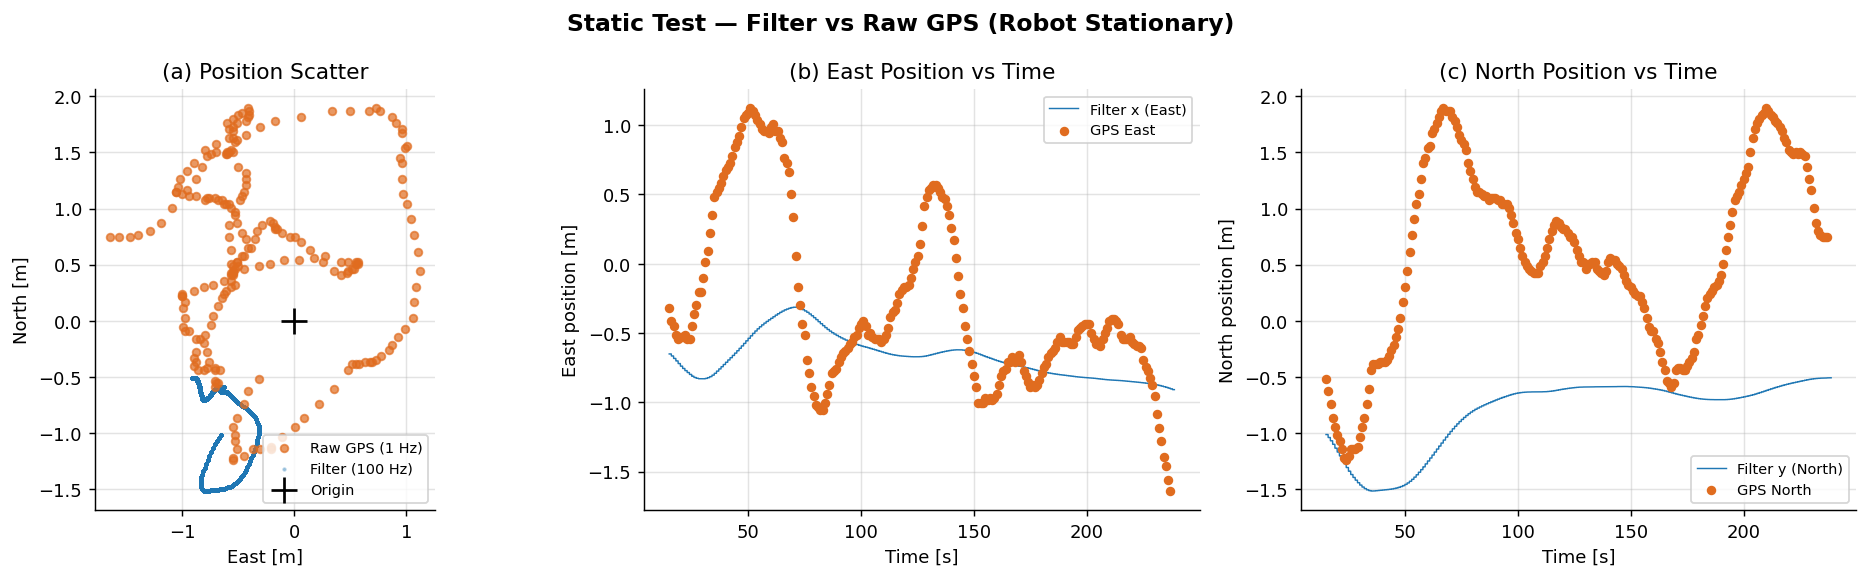

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Static Test — Filter vs Raw GPS (Robot Stationary)', fontsize=13, fontweight='bold')

# ── (a) 2-D scatter ──────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(gps_s_active['east'],  gps_s_active['north'],
           s=18, alpha=0.7, color=GPS_COLOR,    label=f'Raw GPS (1 Hz)',  zorder=3)
ax.scatter(odom_s_active['x'], odom_s_active['y'],
           s=2,  alpha=0.3, color=FILTER_COLOR, label='Filter (100 Hz)', zorder=2)
ax.scatter(0, 0, marker='+', s=200, color='black', zorder=5, label='Origin')
ax.set_aspect('equal')
ax.set_xlabel('East [m]')
ax.set_ylabel('North [m]')
ax.set_title('(a) Position Scatter')
ax.legend(fontsize=8)

# ── (b) East position vs time ─────────────────────────────────────────────
ax = axes[1]
ax.plot(odom_s_active['t_s'], odom_s_active['x'],
        color=FILTER_COLOR, linewidth=0.8, label='Filter x (East)')
ax.scatter(gps_s_active['t_s'], gps_s_active['east'],
           s=18, color=GPS_COLOR, zorder=3, label='GPS East')
ax.set_xlabel('Time [s]')
ax.set_ylabel('East position [m]')
ax.set_title('(b) East Position vs Time')
ax.legend(fontsize=8)

# ── (c) North position vs time ────────────────────────────────────────────
ax = axes[2]
ax.plot(odom_s_active['t_s'], odom_s_active['y'],
        color=FILTER_COLOR, linewidth=0.8, label='Filter y (North)')
ax.scatter(gps_s_active['t_s'], gps_s_active['north'],
           s=18, color=GPS_COLOR, zorder=3, label='GPS North')
ax.set_xlabel('Time [s]')
ax.set_ylabel('North position [m]')
ax.set_title('(c) North Position vs Time')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / '02_Linear_KF_static_measurement' / 'kf_static_position.png', dpi=150)
plt.show()

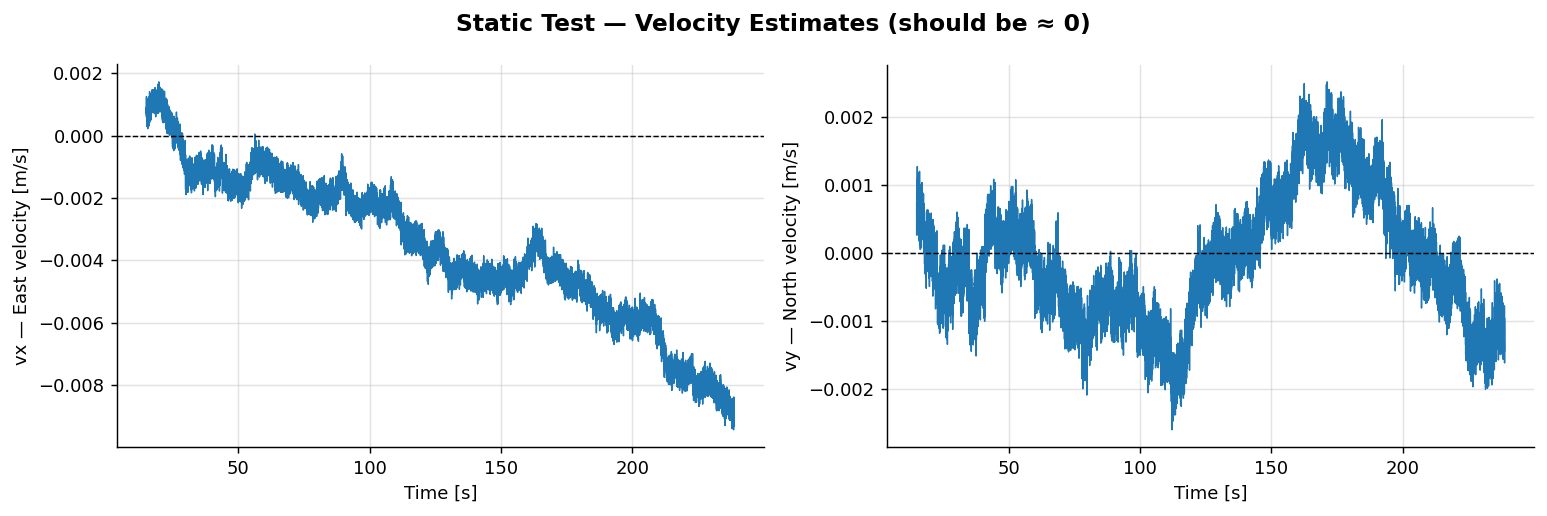

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Static Test — Velocity Estimates (should be ≈ 0)', fontsize=13, fontweight='bold')

for ax, col, label in zip(axes, ['vx', 'vy'], ['vx — East velocity [m/s]', 'vy — North velocity [m/s]']):
    ax.plot(odom_s_active['t_s'], odom_s_active[col],
            color=FILTER_COLOR, linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig(DATA_DIR / '02_Linear_KF_static_measurement' / 'kf_static_velocity.png', dpi=150)
plt.show()

In [6]:
# ── Statistics: noise reduction ───────────────────────────────────────────
# GPS error relative to its own mean
gps_east_err  = gps_s_active['east']  - gps_s_active['east'].mean()
gps_north_err = gps_s_active['north'] - gps_s_active['north'].mean()
gps_r = np.sqrt(gps_east_err**2 + gps_north_err**2)

# Filter error relative to filter mean
filt_east_err  = odom_s_active['x'] - odom_s_active['x'].mean()
filt_north_err = odom_s_active['y'] - odom_s_active['y'].mean()
filt_r = np.sqrt(filt_east_err**2 + filt_north_err**2)

stats = pd.DataFrame({
    'σ East [m]':  [gps_east_err.std(),          filt_east_err.std()],
    'σ North [m]': [gps_north_err.std(),         filt_north_err.std()],
    'CEP50 [m]':   [np.percentile(gps_r, 50),   np.percentile(filt_r, 50)],
    'CEP95 [m]':   [np.percentile(gps_r, 95),   np.percentile(filt_r, 95)],
    'Max |v| [m/s]': [float('nan'),              odom_s_active[['vx','vy']].abs().max().max()],
}, index=['Raw GPS', 'Kalman Filter'])

print('=== Static Test — Position Accuracy Statistics ===')
print(stats.to_string(float_format='{:.4f}'.format))

# Noise reduction factor
red_east  = gps_east_err.std()  / filt_east_err.std()
red_north = gps_north_err.std() / filt_north_err.std()
print(f'\nNoise reduction factor  East: {red_east:.1f}×   North: {red_north:.1f}×')

=== Static Test — Position Accuracy Statistics ===
               σ East [m]  σ North [m]  CEP50 [m]  CEP95 [m]  Max |v| [m/s]
Raw GPS            0.6324       0.8266     0.9580     1.6695            NaN
Kalman Filter      0.1546       0.3185     0.2296     0.6872         0.0094

Noise reduction factor  East: 4.1×   North: 2.6×


---
## 2  Dynamic Test — Straight-Line Movement North (Bag 03)
**Condition**: Robot driven straight North at approximately constant speed, duration ≈ 67 s  
**Goal**: Verify that the filter tracks actual movement and provides smooth 100 Hz output.

In [7]:
dynamic = load_bag(BAG_DYNAMIC, ['/gps/fix', '/odom', '/imu/data_raw'])
gps_d  = dynamic['/gps/fix']
odom_d = dynamic['/odom']
imu_d  = dynamic['/imu/data_raw']

lat0d = gps_d['lat'].iloc[:10].mean()
lon0d = gps_d['lon'].iloc[:10].mean()
gps_d['east'], gps_d['north'] = latlon_to_enu(gps_d['lat'], gps_d['lon'], lat0d, lon0d)

# Active window: after initialization (~15 s)
odom_d_active = odom_d[odom_d['t_s'] > 15].copy()
gps_d_active  = gps_d[gps_d['t_s'] > 15].copy()
imu_d_active  = imu_d[imu_d['t_s'] > 15].copy()

print(f"Dynamic bag — GPS: {len(gps_d_active)} fixes | Odom: {len(odom_d_active)} msgs | IMU: {len(imu_d_active)} msgs")

Dynamic bag — GPS: 52 fixes | Odom: 5233 msgs | IMU: 5232 msgs


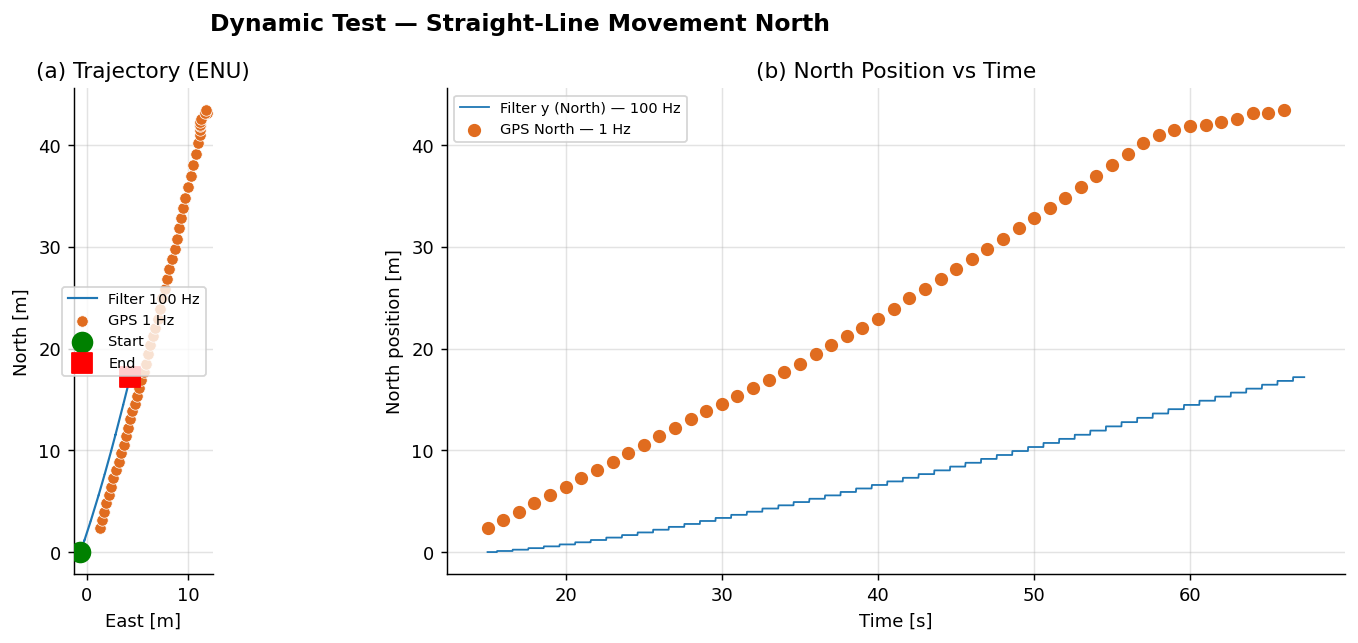

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dynamic Test — Straight-Line Movement North', fontsize=13, fontweight='bold')

# ── (a) 2-D trajectory ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(odom_d_active['x'], odom_d_active['y'],
        color=FILTER_COLOR, linewidth=1.2, label='Filter 100 Hz', zorder=2)
ax.scatter(gps_d_active['east'], gps_d_active['north'],
           s=40, color=GPS_COLOR, zorder=3, label='GPS 1 Hz', edgecolors='white', linewidths=0.4)
ax.scatter(odom_d_active['x'].iloc[0], odom_d_active['y'].iloc[0],
           s=120, marker='o', color='green', zorder=5, label='Start')
ax.scatter(odom_d_active['x'].iloc[-1], odom_d_active['y'].iloc[-1],
           s=120, marker='s', color='red',   zorder=5, label='End')
ax.set_aspect('equal')
ax.set_xlabel('East [m]')
ax.set_ylabel('North [m]')
ax.set_title('(a) Trajectory (ENU)')
ax.legend(fontsize=8)

# ── (b) North position vs time ───────────────────────────────────────────
ax = axes[1]
ax.plot(odom_d_active['t_s'], odom_d_active['y'],
        color=FILTER_COLOR, linewidth=1.0, label='Filter y (North) — 100 Hz')
ax.scatter(gps_d_active['t_s'], gps_d_active['north'],
           s=40, color=GPS_COLOR, zorder=3, label='GPS North — 1 Hz')
ax.set_xlabel('Time [s]')
ax.set_ylabel('North position [m]')
ax.set_title('(b) North Position vs Time')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / '03_Linear_KF_dynamic_measurement_straight' / 'kf_dynamic_trajectory.png', dpi=150)
plt.show()

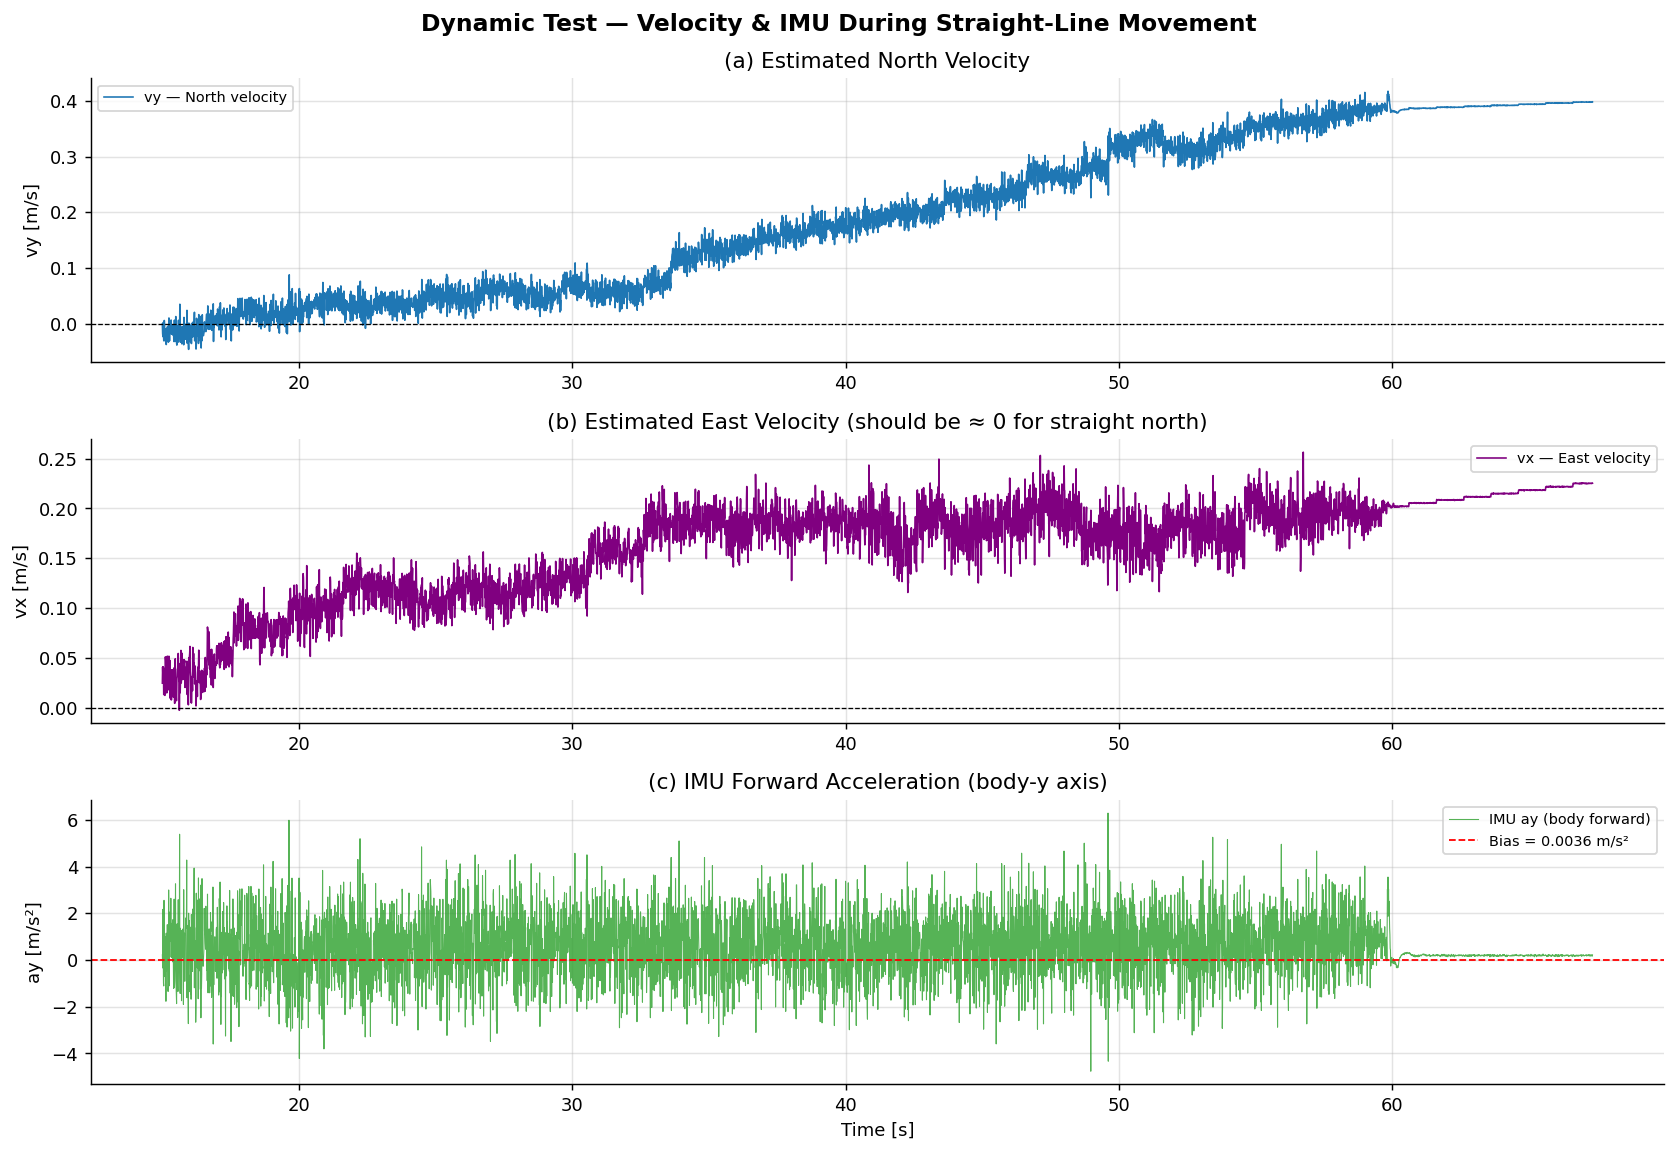

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
fig.suptitle('Dynamic Test — Velocity & IMU During Straight-Line Movement', fontsize=13, fontweight='bold')

# ── (a) North velocity vy ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(odom_d_active['t_s'], odom_d_active['vy'],
        color=FILTER_COLOR, linewidth=0.9, label='vy — North velocity')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_ylabel('vy [m/s]')
ax.set_title('(a) Estimated North Velocity')
ax.legend(fontsize=8)

# ── (b) East velocity vx ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(odom_d_active['t_s'], odom_d_active['vx'],
        color='purple', linewidth=0.9, label='vx — East velocity')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_ylabel('vx [m/s]')
ax.set_title('(b) Estimated East Velocity (should be ≈ 0 for straight north)')
ax.legend(fontsize=8)

# ── (c) IMU forward acceleration (body-y = ay) ────────────────────────────
ax = axes[2]
ax.plot(imu_d_active['t_s'], imu_d_active['ay'],
        color=IMU_COLOR, linewidth=0.6, alpha=0.8, label='IMU ay (body forward)')
imu_bias_ay = imu_d['ay'].iloc[:500].mean()
ax.axhline(imu_bias_ay, color='red', linewidth=1.0,
           linestyle='--', label=f'Bias = {imu_bias_ay:.4f} m/s²')
ax.set_xlabel('Time [s]')
ax.set_ylabel('ay [m/s²]')
ax.set_title('(c) IMU Forward Acceleration (body-y axis)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / '03_Linear_KF_dynamic_measurement_straight' / 'kf_dynamic_velocity_imu.png', dpi=150)
plt.show()

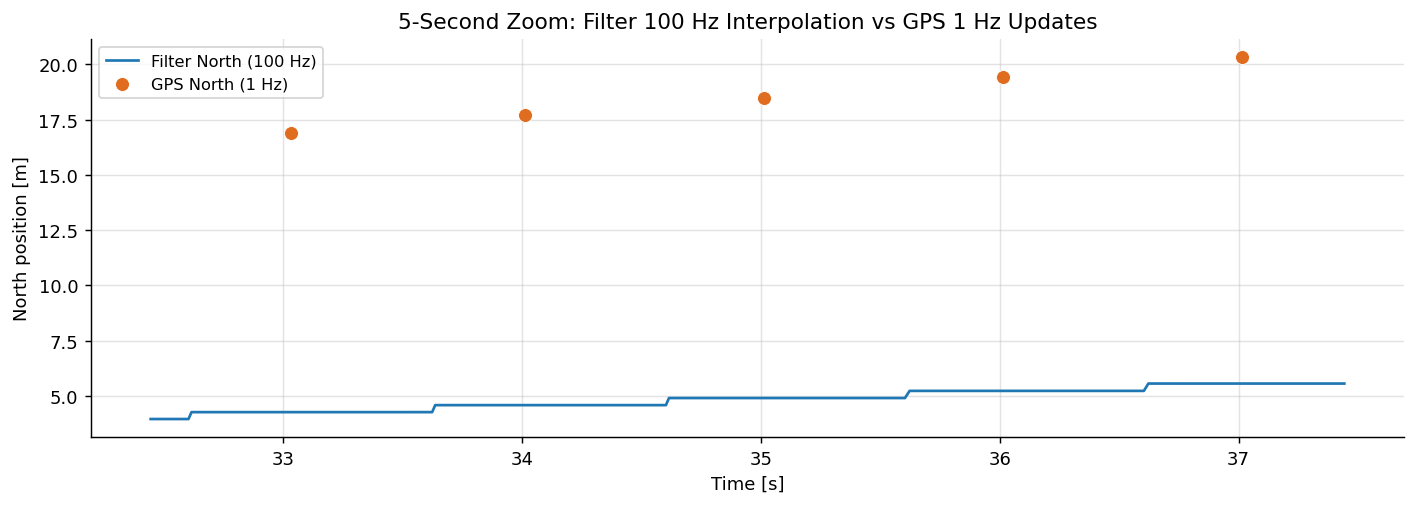

In [10]:
# Zoom into a 5-second window to show 100 Hz interpolation vs 1 Hz GPS jumps
t_zoom_start = odom_d_active['t_s'].iloc[len(odom_d_active)//3]
t_zoom_end   = t_zoom_start + 5.0

odom_z = odom_d_active[(odom_d_active['t_s'] >= t_zoom_start) & (odom_d_active['t_s'] <= t_zoom_end)]
gps_z  = gps_d_active[ (gps_d_active['t_s']  >= t_zoom_start) & (gps_d_active['t_s']  <= t_zoom_end)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(odom_z['t_s'], odom_z['y'],
        color=FILTER_COLOR, linewidth=1.5, label='Filter North (100 Hz)')
ax.scatter(gps_z['t_s'], gps_z['north'],
           s=60, color=GPS_COLOR, zorder=4, label='GPS North (1 Hz)', edgecolors='white', linewidths=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('North position [m]')
ax.set_title('5-Second Zoom: Filter 100 Hz Interpolation vs GPS 1 Hz Updates')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / '03_Linear_KF_dynamic_measurement_straight' / 'kf_dynamic_zoom.png', dpi=150)
plt.show()

---
## 3  Summary

In [11]:
# ── Dynamic movement statistics ───────────────────────────────────────────
total_north_gps    = gps_d_active['north'].iloc[-1]  - gps_d_active['north'].iloc[0]
total_north_filter = odom_d_active['y'].iloc[-1]     - odom_d_active['y'].iloc[0]
peak_vy            = odom_d_active['vy'].max()
duration_dyn       = odom_d_active['t_s'].iloc[-1]   - odom_d_active['t_s'].iloc[0]

print('=== Summary ===')
print()
print('--- Static Test ---')
print(stats.to_string(float_format='{:.4f}'.format))
print(f'  Noise reduction (East / North): {red_east:.1f}× / {red_north:.1f}×')
print()
print('--- Dynamic Test ---')
print(f'  Duration (active):              {duration_dyn:.1f} s')
print(f'  Total North displacement (GPS):    {total_north_gps:.2f} m')
print(f'  Total North displacement (Filter): {total_north_filter:.2f} m')
print(f'  Peak North velocity (vy):          {peak_vy:.3f} m/s')
print(f'  Filter output rate:                100 Hz  (GPS: 1 Hz)')

=== Summary ===

--- Static Test ---
               σ East [m]  σ North [m]  CEP50 [m]  CEP95 [m]  Max |v| [m/s]
Raw GPS            0.6324       0.8266     0.9580     1.6695            NaN
Kalman Filter      0.1546       0.3185     0.2296     0.6872         0.0094
  Noise reduction (East / North): 4.1× / 2.6×

--- Dynamic Test ---
  Duration (active):              52.3 s
  Total North displacement (GPS):    41.01 m
  Total North displacement (Filter): 17.19 m
  Peak North velocity (vy):          0.417 m/s
  Filter output rate:                100 Hz  (GPS: 1 Hz)
